# Checking yields on the Inclusive MC for  template grouping group1

In [1]:
%run load-rds-final-2012-23903000-rs.ipynb

Welcome to JupyROOT 6.28/00


Loaded rdf with 305828 enries


In [2]:
def mygroupby(d, groupbycols):
    g = d.groupby(groupbycols).size().reset_index(name='count').sort_values([ 'count'], ascending=False).reset_index(drop=True)
    g["Percentage"] = g.apply(lambda row: 100 * row["count"]/d.shape[0], axis=1)
    g["cumulative %"] = g["Percentage"].cumsum(axis = 0)
    return g

In [3]:
def categ_groupby(df, groupbycol, threshold):
    """ Group the dataframe df by column groupbycol, grouping together entries rows with count < threshold """
    g = pd.DataFrame(df.groupby(groupbycol).count()["category"]).rename(columns={"category":"count"})
    g["Category"] = g.apply(lambda row: row.name if row["count"] > threshold else "others", axis=1)
    g2 = g.groupby("Category").sum()
    g2 = g2.sort_values([ 'count'], ascending=False)
    total = g2.sum()["count"]
    g2["Percentage"] = g2.apply(lambda row: 100 * row["count"]/total, axis=1)
    g2["cumulative %"] = g2["Percentage"].cumsum(axis = 0)
    return g, g2

In [4]:
import categories4 as f
rdf_initial = rdf
rdf = f.add_categories_and_filter(rdf_initial,  apply_BDT_Iso_cut=True, apply_PIDK_cut=True)

In [5]:
base_columns = [ "eventIndex", "category", "simplified", "B_M", "B_Y_SEP", "Xc_signal_Ypis_displaced_fromBs_fromTau", "fromY_from_B_vertex", "BDT_Iso", "q2_2", "tauY_2"]
load_columns = [
    "Y_0_40_nc_mult",
    "Y_0_20_cc_mult",
    "Y_0_20_cc_PZ",
    "Y_0_30_nc_PZ",
    "Y_0_40_nc_PZ",
    "min_m2pi",
    "max_m2pi",
    "missing_mass_2",
    "B_BPVVDR",
    "B_M",
    "B_correctedMass",
#     "log(abs(PBsn))",
#     "log(abs(PBv/B_P))",
#     "log(abs(PBvn/B_P))",
#     "log(abs((PBsn-PBvn)/PBvn))",
#     "log(sqrt(abs(mDs2vn)))",
    "mN2v",
#    "log(Y_PE)",
    "BDT_Iso",
    "B_pT_Bdir",
    "Y_BPVVDR",
    "missing_pY_mass",
    "Y_correctedMass",
    'PBsn',
    'PBv', 'PBvn', 'B_P', 'mDs2vn', 'Y_PE'
]
train_columns = [
    "Y_0_40_nc_mult",
    "Y_0_20_cc_mult",
    "Y_0_20_cc_PZ",
    "Y_0_30_nc_PZ",
    "Y_0_40_nc_PZ",
    "min_m2pi",
    "max_m2pi",
    "missing_mass_2",
    "B_BPVVDR",
    "B_M",
    "B_correctedMass",
    "log(abs(PBsn))",
    "log(abs(PBv/B_P))",
    "log(abs(PBvn/B_P))",
    "log(abs((PBsn-PBvn)/PBvn))",
    "log(sqrt(abs(mDs2vn)))",
    "mN2v",
    "log(Y_PE)",
    "BDT_Iso",
    "B_pT_Bdir",
    "Y_BPVVDR",
    "missing_pY_mass",
    "Y_correctedMass",
]

columns = base_columns +  load_columns
df = pd.DataFrame(rdf.Cache(columns).AsNumpy())


In [6]:
df['simplified_key'] = df.apply(lambda row: f.pretty_categories_map[row["simplified"]], axis=1)
df['key'] = df.apply(lambda row: f.categories_map[row["category"]], axis=1)
df['signal'] = (df['simplified_key'] == 'Signal')
dfbm = df.query("B_M < 5000")

In [7]:
df.query("B_M < 5000").query("signal == True").query("q2_2 > 0")

,BDT_Iso,B_BPVVDR,B_M,B_P,B_Y_SEP,B_correctedMass,B_pT_Bdir,PBsn,PBv,PBvn,...,max_m2pi,min_m2pi,missing_mass_2,missing_pY_mass,q2_2,simplified,tauY_2,simplified_key,key,signal
18,0.300701,1.251786,3555.436260,73440.504631,-5.396421,4648.655407,964.673579,95030.086006,119258.329865,102598.838899,...,717.463194,326.297603,634.665738,-309.581326,7.492151,1007,0.000324,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
27,0.304464,2.207561,4295.377515,161397.486742,-13.755033,4867.665362,538.646115,218321.801510,227549.612874,218321.949795,...,1136.189727,631.568058,341.499885,317.509062,4.852885,1007,0.000512,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
191,0.399764,3.409034,4101.212991,144294.265574,-29.192873,5547.156730,1257.491041,123290.341564,132639.509066,130663.716106,...,711.771211,547.652312,-1185.865988,536.725748,7.190575,1007,0.000946,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
192,0.060515,1.316995,4603.941355,152274.692578,-17.808110,5027.680017,405.882071,148826.309470,151727.047076,148868.065327,...,873.148779,786.979971,-356.337971,396.317398,5.524680,1007,0.000726,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
274,0.316373,1.963349,4468.346674,191079.648151,-6.288015,5286.581659,754.913492,161847.575966,179169.819382,161867.100541,...,721.087590,655.613555,-754.646648,517.683761,6.000162,1007,0.000149,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242268,0.235340,1.554001,3972.670890,207990.577214,-7.814765,5305.832564,1165.674289,292365.048373,351147.073467,316351.741998,...,932.845543,836.936942,-971.323028,486.019541,3.913299,1007,0.000234,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
242374,0.430140,6.910549,3387.932555,77325.281992,-23.642952,3737.534285,333.251195,81476.991060,88985.847274,81830.132992,...,595.212368,570.175348,852.768024,838.358234,8.128510,1007,0.000633,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
242395,0.198366,2.908379,3819.010212,90789.831007,-7.146156,4266.577350,424.092075,107943.957038,116331.299456,107979.802988,...,891.375999,764.576723,758.678435,529.004453,6.473756,1007,0.000470,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
242476,0.229566,1.213361,4300.833408,145979.948903,-8.153945,5283.667754,891.424042,127477.921173,131290.652600,127653.882759,...,759.718200,435.177340,-815.592170,463.230325,7.859131,1007,0.000334,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True


In [8]:
dfbm.query("BDT_Iso <  0.03458")

,BDT_Iso,B_BPVVDR,B_M,B_P,B_Y_SEP,B_correctedMass,B_pT_Bdir,PBsn,PBv,PBvn,...,max_m2pi,min_m2pi,missing_mass_2,missing_pY_mass,q2_2,simplified,tauY_2,simplified_key,key,signal


THIS INCLUDES THE CUT q2_2 > 0 BY DEFAULT

In [ ]:
import joblib
bdtdblcharm = joblib.load("../../train_bdt/bdtdblcharm_150_3_0.04.pkl")
def add_cols_for_bdt(tmpdf):
    df = tmpdf.copy()
    df["log(abs(PBsn))"] = np.log(np.abs(df["PBsn"]))
    df["log(abs(PBv/B_P))"] = np.log(np.abs(df["PBv"] / df["B_P"]))
    df["log(abs(PBvn/B_P))"] = np.log(np.abs(df["PBvn"] / df["B_P"]))
    df["log(abs((PBsn-PBvn)/PBvn))"] = np.log(np.abs((df["PBsn"] - df["PBvn"]) / df["PBvn"]))
    df["log(sqrt(abs(mDs2vn)))"] = np.log(np.sqrt(np.abs(df["mDs2vn"])))
    df["log(Y_PE)"] = np.log(df["Y_PE"]) 
    df["diff_m2pi"] = df["max_m2pi"] - df["min_m2pi"]
    return df
dfbm2 = add_cols_for_bdt(dfbm)

In [10]:
dfbm2['bdt_dc'] = bdtdblcharm.predict_proba(dfbm2[train_columns])[:,1]

In [11]:
#dfbm2.to_hdf('data_with_bdt_dc.h5', key='df', mode='w')

In [12]:
dfbm2.query("signal == True")['category'].unique()

array([24, 10, 11], dtype=int32)

In [13]:
f.categories_map

{0: 'Xc_background',
 1: 'Xc_signal_Ypis_diffAncestorYXc',
 2: 'Xc_signal_Ypis_B_vertex_fromBs',
 3: 'Xc_signal_Ypis_B_vertex_fromOtherB',
 4: 'Xc_signal_Ypis_B_vertex_fromHc',
 5: 'Xc_signal_Ypis_B_vertex_fromNone',
 6: 'Xc_signal_Ypis_nomatch_Prompt',
 7: 'Xc_signal_Ypis_nomatch_doubleCharm',
 8: 'Xc_signal_Ypis_nomatch_charmStrange',
 9: 'Xc_signal_Ypis_nomatch_Other',
 10: 'Xc_signal_Ypis_diffVertex_signal',
 11: 'Xc_signal_Ypis_diffVertex_tauFromB',
 12: 'Xc_signal_Ypis_diffVertex_normlike',
 13: 'Xc_signal_Ypis_diffVertex_doubleCharm',
 14: 'Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB',
 15: 'Xc_signal_Ypis_diffVertex_doubleCharm_TwoFromB',
 16: 'Xc_signal_Ypis_diffVertex_CharmStrange',
 17: 'Xc_signal_Ypis_diffVertex_SomeFromPV',
 18: 'Xc_signal_Ypis_displaced_fromBs_fromDs',
 19: 'Xc_signal_Ypis_displaced_fromB0_fromDp',
 20: 'Xc_signal_Ypis_displaced_fromBp_fromD0',
 21: 'Xc_signal_Ypis_displaced_fromLambdab_fromLambdac',
 22: 'Xc_signal_Ypis_displaced_fromBs_fromDp',
 23: 

In [14]:
dfbm2

,BDT_Iso,B_BPVVDR,B_M,B_P,B_Y_SEP,B_correctedMass,B_pT_Bdir,PBsn,PBv,PBvn,...,key,signal,log(abs(PBsn)),log(abs(PBv/B_P)),log(abs(PBvn/B_P)),log(abs((PBsn-PBvn)/PBvn)),log(sqrt(abs(mDs2vn))),log(Y_PE),diff_m2pi,bdt_dc
0,0.142126,5.122865,3549.868167,168977.117807,-42.580564,4429.095708,791.959042,213931.912377,227255.066624,224798.696179,...,Xc_background,False,12.273413,0.296310,0.285442,-3.029495,7.911052,10.883605,414.693391,0.480915
1,0.084323,1.668125,3319.233948,61299.597437,-25.553933,3650.446180,316.186461,68422.978613,75375.247132,68627.893311,...,Xc_background,False,11.133464,0.206706,0.112926,-5.813861,7.786525,9.734375,197.234971,0.047678
2,0.368573,1.993594,3952.608126,156837.935763,-10.530797,4331.339197,362.173002,193830.018453,206759.162365,194002.880756,...,Xc_signal_Ypis_displaced_fromB0_fromDp,False,12.174737,0.276342,0.212660,-7.023133,7.734093,11.047794,35.228538,0.550376
3,0.152137,0.780185,3590.944305,86795.626730,-5.040866,4689.721792,970.058554,63525.280784,74187.153322,64659.427607,...,Xc_background,False,11.059193,-0.156965,-0.294422,-4.043253,7.936118,10.755483,143.757553,0.744786
4,0.382045,1.299142,3747.756129,148853.385470,-5.497857,4000.589420,244.843884,152223.181078,163115.939253,152258.133512,...,Xc_signal_Ypis_displaced_fromBs_fromDs,False,11.933103,0.091499,0.022615,-8.379345,7.086510,9.932745,56.547468,0.057617
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242735,0.321024,4.012284,4027.889398,202833.051607,-20.939083,5027.599310,900.316559,278687.778202,301173.947829,286704.281254,...,Xc_signal_Ypis_displaced_fromBs_fromDs,False,12.537847,0.395305,0.346068,-3.576949,7.392935,11.387447,558.693289,0.197994
242736,0.132013,0.912369,4565.097589,171913.729033,-12.364674,5011.791461,426.787276,169474.374381,172384.198847,169695.757786,...,Xc_signal_Ypis_displaced_fromBs_fromDs,False,12.040457,0.002733,-0.012986,-6.641866,7.637914,10.947215,93.671025,0.435207
242737,0.340379,1.283536,4689.555203,142928.520106,-29.903899,6174.122483,1306.085235,123794.055575,126366.400090,123879.637927,...,Xc_signal_Ypis_displaced_fromBs_fromDs,False,11.726375,-0.123159,-0.143034,-7.277587,7.654822,10.930162,275.300333,0.302139
242738,0.266166,1.156650,3400.800053,108148.088194,-5.197422,4531.720777,989.806372,145142.143730,176817.601762,145184.537346,...,Xc_signal_Ypis_nomatch_doubleCharm,False,11.885469,0.491617,0.294504,-8.138763,7.694428,10.076992,399.626947,0.345274


# Loading the template

In [15]:
import yaml
from yaml import SafeLoader
# Loading the template configuration
with open("../config/templates.yaml") as yf:
    templates_config = yaml.load(yf, Loader=SafeLoader)

In [16]:
group1 = templates_config['templates']['group1']

In [17]:
print(group1)
group1_map = {}
group1_others = None
for i, c in enumerate(group1):
    if type(c) == int:
        group1_map[c] = i
    elif c == 'others':
        group1_others = i
    else:
        for cc in c:
            if cc == 'others':
                group1_others = i
            else:
                group1_map[cc] = i
print(group1_map)

def get_group1_categories(bkgcat):
    return group1[group1_map.get(bkgcat, group1_others)]

def _g1cat2name(cat):
    if type(cat) == int:
        tmp = f.categories_map[cat]
        if tmp == "Xc_signal_Ypis_displaced_fromBs_fromTau":
            return "Signal"
        elif tmp in ['Xc_signal_Ypis_diffVertex_signal', 'Xc_signal_Ypis_diffVertex_tauFromB']:
            return None
        return tmp.replace("Xc_signal_Ypis_", "")
    elif cat == 'others':
        return 'others'
    elif type(cat) == list:
        #print(cat)
        catnames = [ _g1cat2name(c) for c in cat]
        #print(f"===> {catnames}")
        return ", ".join([cc for cc in catnames if cc is not None])
        #return ", ".join([cc for cc in catnames in cc is not None])
 

def _get_group1_name(c):
    #print(f"==>categ {c}")
    return _g1cat2name(group1[int(c)])


[18, 29, 23, [24, 10, 11], [15, 0, 'others'], [16, 14], [25, 7, 19, 13], [27, 22], 20, 26, 21]
{18: 0, 29: 1, 23: 2, 24: 3, 10: 3, 11: 3, 15: 4, 0: 4, 16: 5, 14: 5, 25: 6, 7: 6, 19: 6, 13: 6, 27: 7, 22: 7, 20: 8, 26: 9, 21: 10}


In [18]:
dfbm2['group1_category'] = dfbm2.apply(lambda row: group1_map.get(row['category'], group1_others), axis=1)
dfbm2['group1_name'] = dfbm2.apply(lambda row: _get_group1_name(row['group1_category']), axis=1)
#dfbm2



In [19]:
pd.set_option('display.max_colwidth', None)
stat_g1 = mygroupby(dfbm2, 'group1_name')

# Correlations between the variables for each group

In [20]:
dfbm2[['q2_2', 'tauY_2', "bdt_dc", 'group1_name']].corr()

/tmp/ipykernel_367661/732302729.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  dfbm2[['q2_2', 'tauY_2', "bdt_dc", 'group1_name']].corr()


,q2_2,tauY_2,bdt_dc
q2_2,1.000000,0.000772,0.188696
tauY_2,0.000772,1.000000,-0.066909
bdt_dc,0.188696,-0.066909,1.000000


## Evaluating datasets after cuts

In [21]:
df_cut1 = dfbm2.query("bdt_dc >0.75")

In [22]:
stat_g1 = mygroupby(df_cut1, 'group1_name')
stat_g1.set_index('group1_name', inplace=True)
signal_count = int(232 * stat_g1.loc['Signal', 'count'] / 3562)
print(f"Ratio of candidates in current sample vs 2invfb {3562/232}")
signal_percentage = stat_g1.loc['Signal', 'Percentage'] 
print(f"{signal_percentage} ==> {signal_count}")
ratio = signal_count / signal_percentage
print(ratio)
stat_g1['yield_2invfb'] = stat_g1.apply(lambda row: int(row['Percentage'] * ratio), axis=1)
stat_g1['name'] = stat_g1.index
stat_g1['empty'] = ""
stat_g1

Ratio of candidates in current sample vs 2invfb 15.35344827586207
10.7387089501766 ==> 93
8.660258922323303


,count,Percentage,cumulative %,yield_2invfb,name,empty
group1_name,,,,,,
"displaced_fromB0_fromD0, nomatch_doubleCharm, displaced_fromB0_fromDp, diffVertex_doubleCharm",4044,30.390020,30.390020,263,"displaced_fromB0_fromD0, nomatch_doubleCharm, displaced_fromB0_fromDp, diffVertex_doubleCharm",
"diffVertex_doubleCharm_TwoFromB, Xc_background, others",1887,14.180507,44.570527,122,"diffVertex_doubleCharm_TwoFromB, Xc_background, others",
"displaced_fromBs_fromD0, displaced_fromBs_fromDp",1781,13.383933,57.954460,115,"displaced_fromBs_fromD0, displaced_fromBs_fromDp",
Signal,1429,10.738709,68.693169,93,Signal,
"diffVertex_CharmStrange, diffVertex_doubleCharm_OneFromB",1388,10.430600,79.123769,90,"diffVertex_CharmStrange, diffVertex_doubleCharm_OneFromB",
displaced_fromBs_fromDs,766,5.756369,84.880138,49,displaced_fromBs_fromDs,
displaced_fromBp_fromD0,731,5.493349,90.373488,47,displaced_fromBp_fromD0,
displaced_fromBp_fromDp,720,5.410686,95.784174,46,displaced_fromBp_fromDp,
displaced_fromLambdab_fromLambdac,278,2.089126,97.873300,18,displaced_fromLambdab_fromLambdac,


In [23]:
print(stat_g1[['empty', 'name', 'Percentage', 'yield_2invfb']].to_latex(float_format="%.2f", index=False))

\begin{tabular}{llrr}
\toprule
empty &                                                                                          name &  Percentage &  yield\_2invfb \\
      & displaced\_fromB0\_fromD0, nomatch\_doubleCharm, displaced\_fromB0\_fromDp, diffVertex\_doubleCharm &       30.39 &           263 \\
\midrule
      &                                        diffVertex\_doubleCharm\_TwoFromB, Xc\_background, others &       14.18 &           122 \\
      &                                              displaced\_fromBs\_fromD0, displaced\_fromBs\_fromDp &       13.38 &           115 \\
      &                                                                                        Signal &       10.74 &            93 \\
      &                                      diffVertex\_CharmStrange, diffVertex\_doubleCharm\_OneFromB &       10.43 &            90 \\
      &                                                                       displaced\_fromBs\_fromDs &        5.76 &            49

/tmp/ipykernel_367661/1193698796.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(stat_g1[['empty', 'name', 'Percentage', 'yield_2invfb']].to_latex(float_format="%.2f", index=False))


In [24]:
df_cut2 = dfbm2.query("bdt_dc >0.35")
stat_g2 = mygroupby(df_cut2, 'group1_name')
stat_g2.set_index('group1_name', inplace=True)
signal_count = int(232 * stat_g2.loc['Signal', 'count'] / 3562)
signal_percentage = stat_g2.loc['Signal', 'Percentage'] 
print(f"{signal_percentage} ==> {signal_count}")
ratio = signal_count / signal_percentage
stat_g2['yield_2invfb'] = stat_g2.apply(lambda row: int(row['Percentage'] * ratio), axis=1)
stat_g2['name'] = stat_g2.index
stat_g2['empty'] = ""
print(stat_g2[['empty', 'name', 'Percentage', 'yield_2invfb']].to_latex(float_format="%.2f", index=False))
stat_g2

3.3072859344045784 ==> 195
\begin{tabular}{llrr}
\toprule
empty &                                                                                          name &  Percentage &  yield\_2invfb \\
      & displaced\_fromB0\_fromD0, nomatch\_doubleCharm, displaced\_fromB0\_fromDp, diffVertex\_doubleCharm &       33.67 &          1985 \\
\midrule
      &                                      diffVertex\_CharmStrange, diffVertex\_doubleCharm\_OneFromB &       13.20 &           778 \\
      &                                                                       displaced\_fromBs\_fromDs &       13.03 &           768 \\
      &                                        diffVertex\_doubleCharm\_TwoFromB, Xc\_background, others &       12.40 &           731 \\
      &                                                                       displaced\_fromBp\_fromD0 &        8.26 &           487 \\
      &                                              displaced\_fromBs\_fromD0, displaced\_fromBs\_fromDp 

/tmp/ipykernel_367661/3953410342.py:11: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(stat_g2[['empty', 'name', 'Percentage', 'yield_2invfb']].to_latex(float_format="%.2f", index=False))


,count,Percentage,cumulative %,yield_2invfb,name,empty
group1_name,,,,,,
"displaced_fromB0_fromD0, nomatch_doubleCharm, displaced_fromB0_fromDp, diffVertex_doubleCharm",30590,33.667180,33.667180,1985,"displaced_fromB0_fromD0, nomatch_doubleCharm, displaced_fromB0_fromDp, diffVertex_doubleCharm",
"diffVertex_CharmStrange, diffVertex_doubleCharm_OneFromB",11996,13.202729,46.869910,778,"diffVertex_CharmStrange, diffVertex_doubleCharm_OneFromB",
displaced_fromBs_fromDs,11837,13.027735,59.897645,768,displaced_fromBs_fromDs,
"diffVertex_doubleCharm_TwoFromB, Xc_background, others",11266,12.399296,72.296940,731,"diffVertex_doubleCharm_TwoFromB, Xc_background, others",
displaced_fromBp_fromD0,7508,8.263262,80.560203,487,displaced_fromBp_fromD0,
"displaced_fromBs_fromD0, displaced_fromBs_fromDp",7218,7.944090,88.504292,468,"displaced_fromBs_fromD0, displaced_fromBs_fromDp",
displaced_fromBp_fromDp,3415,3.758530,92.262822,221,displaced_fromBp_fromDp,
Signal,3005,3.307286,95.570108,195,Signal,
displaced_fromLambdab_fromLambdac,2424,2.667841,98.237948,157,displaced_fromLambdab_fromLambdac,


In [25]:
df_cut3 = dfbm2.query("bdt_dc >0.50")
stat_g3 = mygroupby(df_cut3, 'group1_name')
stat_g3.set_index('group1_name', inplace=True)
signal_count = int(232 * stat_g3.loc['Signal', 'count'] / 3562)
signal_percentage = stat_g3.loc['Signal', 'Percentage'] 
print(f"{signal_percentage} ==> {signal_count}")
ratio = signal_count / signal_percentage
stat_g3['yield_2invfb'] = stat_g3.apply(lambda row: int(row['Percentage'] * ratio), axis=1)
stat_g3['name'] = stat_g3.index
stat_g3['empty'] = ""
print(stat_g3[['empty', 'name', 'Percentage', 'yield_2invfb']].to_latex(float_format="%.2f", index=False))

4.811940741840864 ==> 168
\begin{tabular}{llrr}
\toprule
empty &                                                                                          name &  Percentage &  yield\_2invfb \\
      & displaced\_fromB0\_fromD0, nomatch\_doubleCharm, displaced\_fromB0\_fromDp, diffVertex\_doubleCharm &       33.48 &          1169 \\
\midrule
      &                                        diffVertex\_doubleCharm\_TwoFromB, Xc\_background, others &       12.94 &           451 \\
      &                                      diffVertex\_CharmStrange, diffVertex\_doubleCharm\_OneFromB &       12.79 &           446 \\
      &                                                                       displaced\_fromBs\_fromDs &       10.27 &           358 \\
      &                                              displaced\_fromBs\_fromD0, displaced\_fromBs\_fromDp &        9.31 &           325 \\
      &                                                                       displaced\_fromBp\_fromD0 &

/tmp/ipykernel_367661/104527034.py:11: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(stat_g3[['empty', 'name', 'Percentage', 'yield_2invfb']].to_latex(float_format="%.2f", index=False))


# Checking the correlations within the group

In [26]:
group1

[18,
 29,
 23,
 [24, 10, 11],
 [15, 0, 'others'],
 [16, 14],
 [25, 7, 19, 13],
 [27, 22],
 20,
 26,
 21]

In [27]:
all_others = [ c for c in dfbm2['category'].unique() if c not in group1_map ]
all_others
to_check = [] 
for i, g in enumerate(group1):
    if type(g) == list:
        print(g)

[24, 10, 11]
[15, 0, 'others']
[16, 14]
[25, 7, 19, 13]
[27, 22]


In [28]:
dfbm2.query("category == 15")[['q2_2', 'tauY_2', "bdt_dc"]].corr()

,q2_2,tauY_2,bdt_dc
q2_2,1.000000,-0.110613,0.139757
tauY_2,-0.110613,1.000000,-0.123434
bdt_dc,0.139757,-0.123434,1.000000


In [29]:
dfbm2.query("category == 0")[['q2_2', 'tauY_2', "bdt_dc"]].corr()

,q2_2,tauY_2,bdt_dc
q2_2,1.000000,-0.042752,0.216175
tauY_2,-0.042752,1.000000,-0.098170
bdt_dc,0.216175,-0.098170,1.000000


In [30]:
dfbm2.query("category == 27")[['q2_2', 'tauY_2', "bdt_dc"]].corr()

,q2_2,tauY_2,bdt_dc
q2_2,1.000000,-0.122684,0.080803
tauY_2,-0.122684,1.000000,-0.172539
bdt_dc,0.080803,-0.172539,1.000000


In [31]:

dfbm2.query("category == 22")[['q2_2', 'tauY_2', "bdt_dc"]].corr()

,q2_2,tauY_2,bdt_dc
q2_2,1.000000,-0.015733,0.172220
tauY_2,-0.015733,1.000000,-0.094319
bdt_dc,0.172220,-0.094319,1.000000


# Checking category [22, 27]

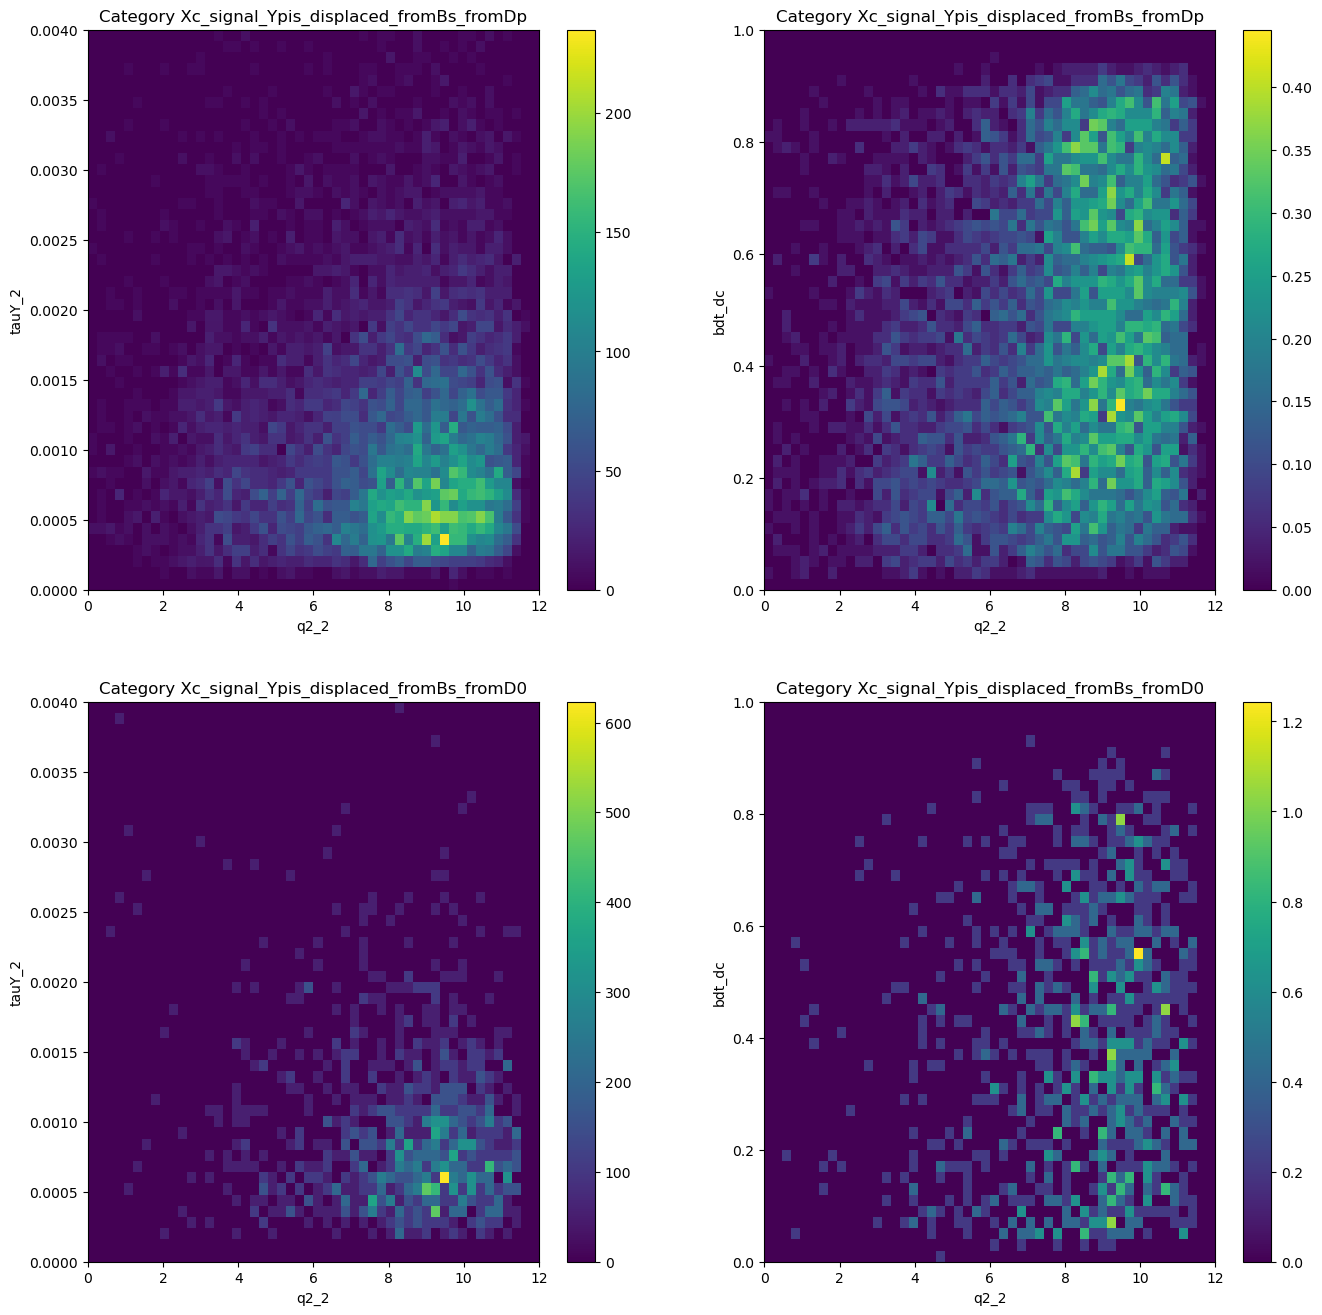

In [43]:
category1 = 22
category2 = 27


ranges = {
    'tauY_2': [ 0, 0.004],
    'bdt_dc': [ 0, 1],
    'q2_2': [ 0, 12.0],
}

def myplot(df, category, var1, var2, ax, bins=50):
    h = ax.hist2d(df[var1], df[var2], bins=bins, density=True, range=[ranges[var1], ranges[var2]]);
    ax.set_xlabel(var1)
    ax.set_ylabel(var2)
    title = "Others"
    if category < 999:
        title = f"Category {f.categories_map[category]}"
    ax.set_title(title)
    fig.colorbar(h[3], ax=ax)

dftmp1 = dfbm2.query(f"category == {category1}")
dftmp2 = dfbm2.query(f"category == {category2}")

fig, axs = plt.subplots(2, 2, figsize=(16, 16))
myplot(dftmp1, 22, 'q2_2', 'tauY_2', axs[0][0])
myplot(dftmp2, 27, 'q2_2', 'tauY_2', axs[1][0])
myplot(dftmp1, 22, 'q2_2', 'bdt_dc', axs[0][1])
myplot(dftmp2, 27, 'q2_2', 'bdt_dc', axs[1][1])
fig.savefig(f"2D_corr_{category1}_{category2}.png")

# Checking category [16, 14]

Xc_signal_Ypis_diffVertex_CharmStrange
Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB


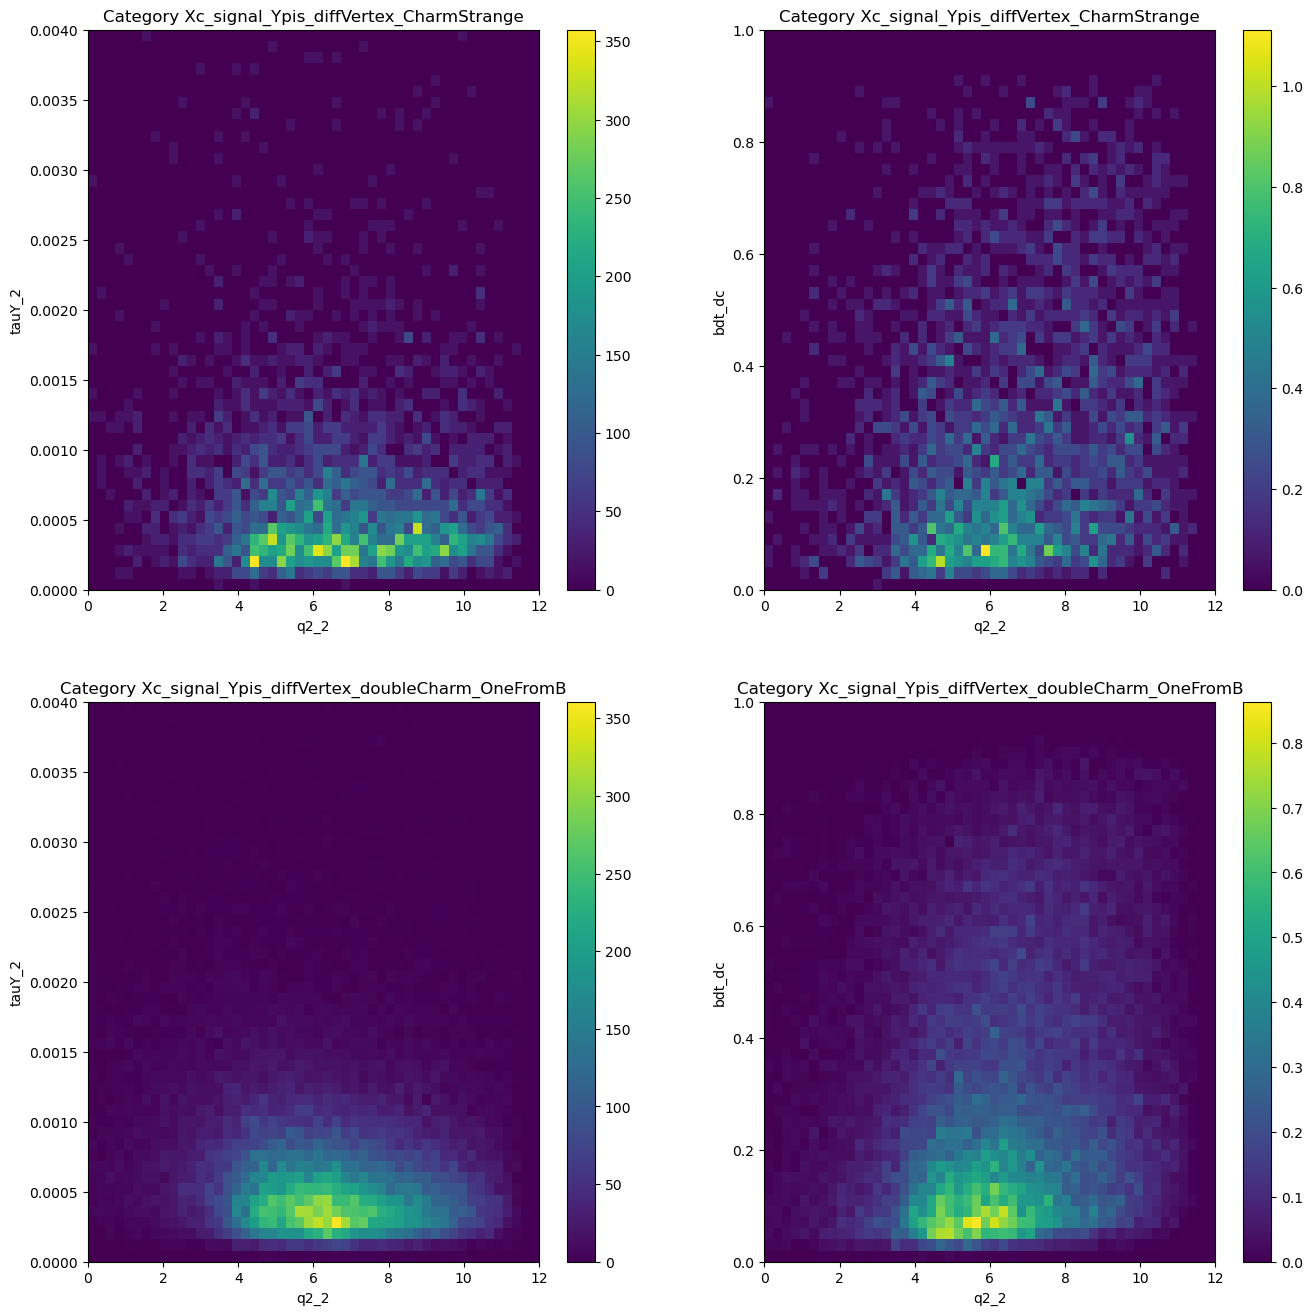

In [45]:
category1 = 16
category2 = 14


print(f.categories_map[category1])
print(f.categories_map[category2])

dftmp1 = dfbm2.query(f"category == {category1}")
dftmp2 = dfbm2.query(f"category == {category2}")

fig, axs = plt.subplots(2, 2, figsize=(16, 16))
myplot(dftmp1, category1, 'q2_2', 'tauY_2', axs[0][0])
myplot(dftmp2, category2, 'q2_2', 'tauY_2', axs[1][0])
myplot(dftmp1, category1, 'q2_2', 'bdt_dc', axs[0][1])
myplot(dftmp2, category2, 'q2_2', 'bdt_dc', axs[1][1])
fig.savefig(f"2D_corr_{category1}_{category2}.png")

# Checking category [25, 7, 19, 13]

Xc_signal_Ypis_displaced_fromB0_fromD0
Xc_signal_Ypis_nomatch_doubleCharm


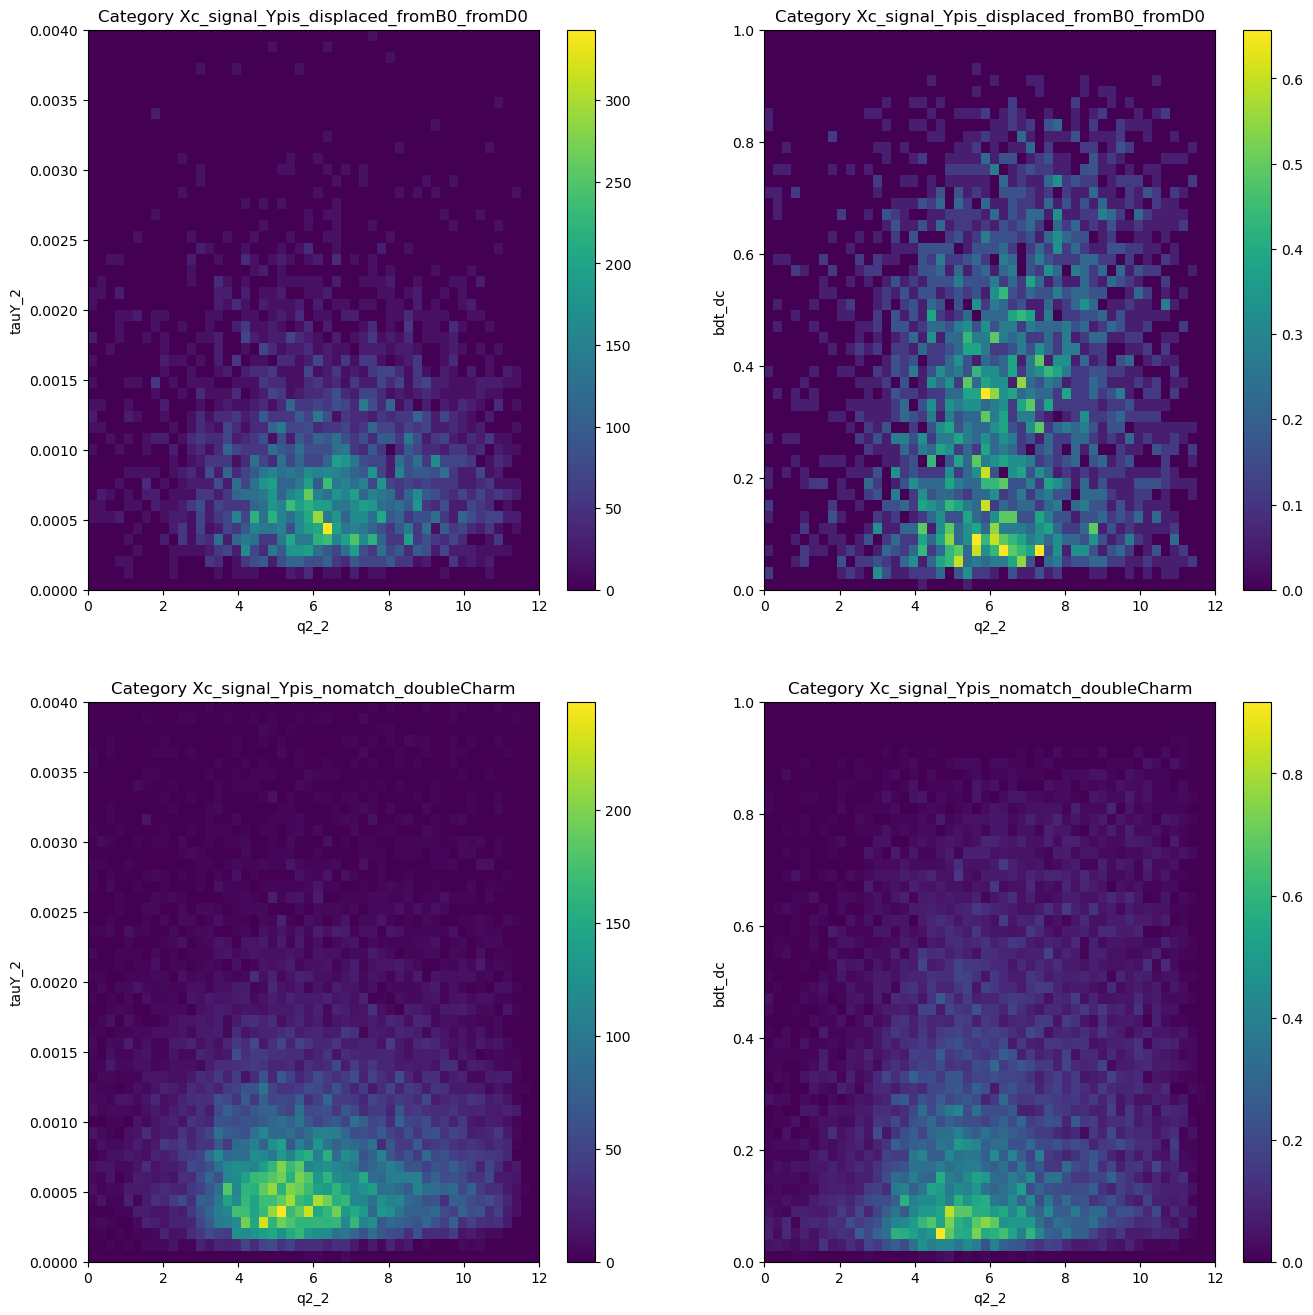

In [46]:
category1 = 25
category2 = 7


print(f.categories_map[category1])
print(f.categories_map[category2])

dftmp1 = dfbm2.query(f"category == {category1}")
dftmp2 = dfbm2.query(f"category == {category2}")

fig, axs = plt.subplots(2, 2, figsize=(16, 16))
myplot(dftmp1, category1, 'q2_2', 'tauY_2', axs[0][0])
myplot(dftmp2, category2, 'q2_2', 'tauY_2', axs[1][0])
myplot(dftmp1, category1, 'q2_2', 'bdt_dc', axs[0][1])
myplot(dftmp2, category2, 'q2_2', 'bdt_dc', axs[1][1])
fig.savefig(f"2D_corr_{category1}_{category2}.png")

Xc_signal_Ypis_displaced_fromB0_fromDp
Xc_signal_Ypis_diffVertex_doubleCharm


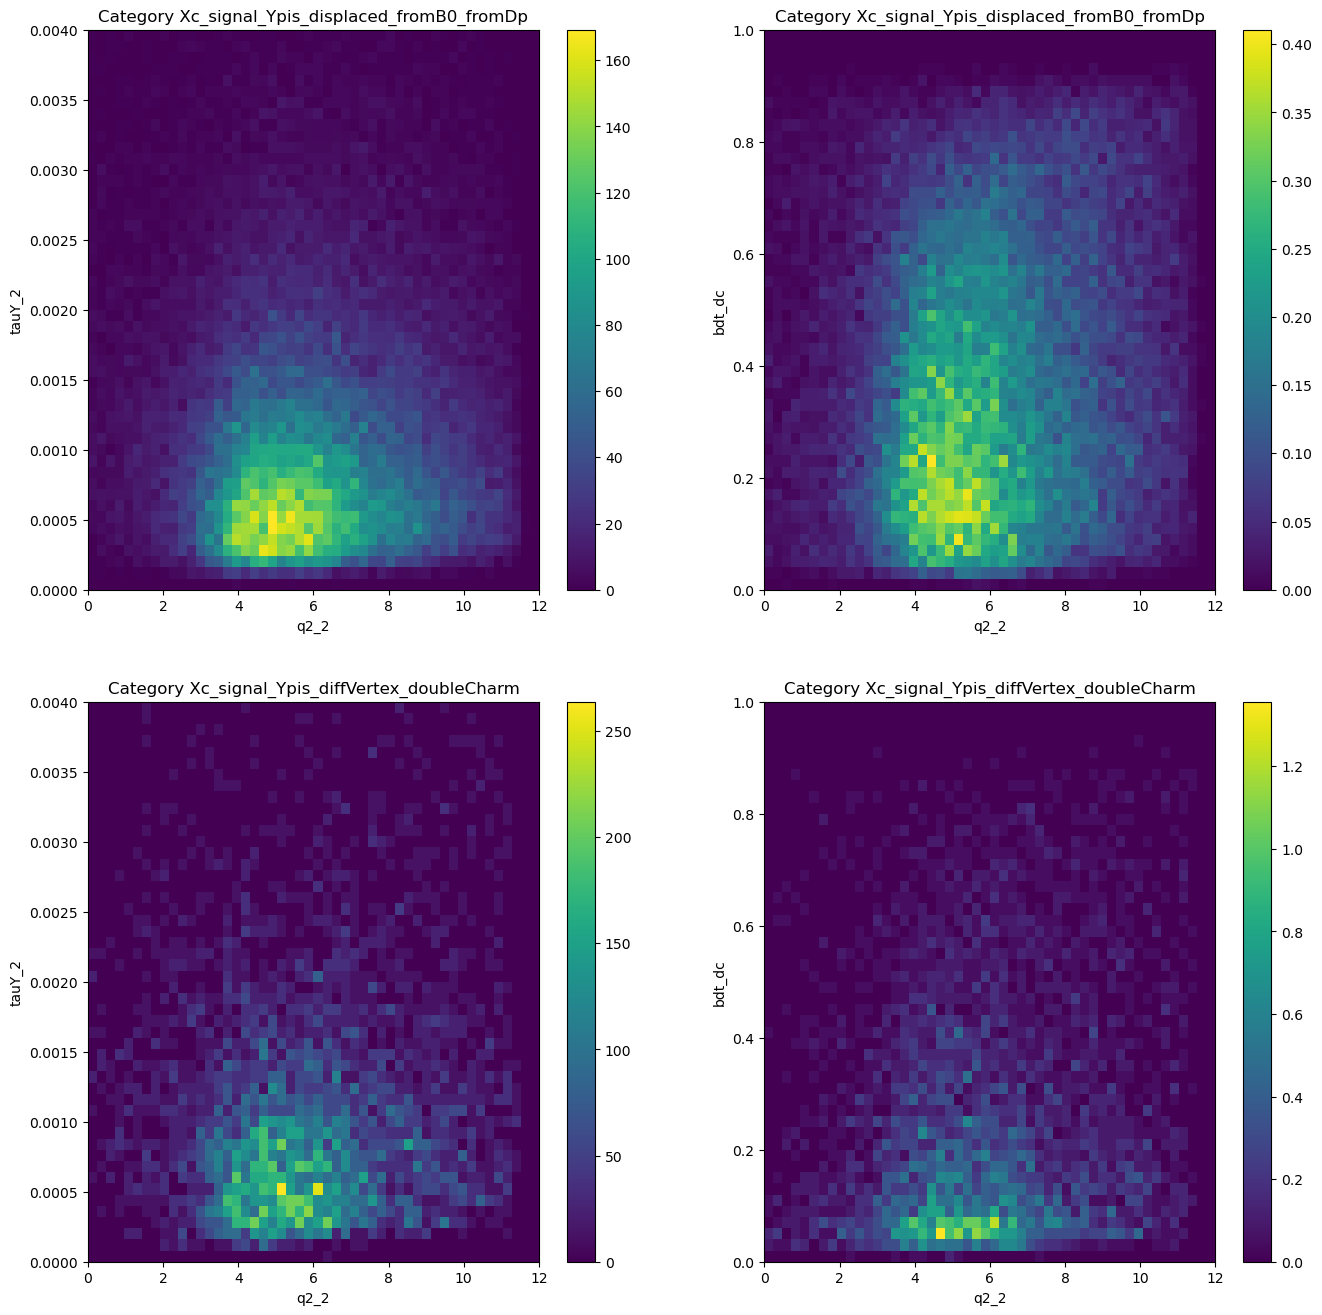

In [47]:
category1 = 19
category2 = 13



print(f.categories_map[category1])
print(f.categories_map[category2])


dftmp1 = dfbm2.query(f"category == {category1}")
dftmp2 = dfbm2.query(f"category == {category2}")

fig, axs = plt.subplots(2, 2, figsize=(16, 16))
myplot(dftmp1, category1, 'q2_2', 'tauY_2', axs[0][0])
myplot(dftmp2, category2, 'q2_2', 'tauY_2', axs[1][0])
myplot(dftmp1, category1, 'q2_2', 'bdt_dc', axs[0][1])
myplot(dftmp2, category2, 'q2_2', 'bdt_dc', axs[1][1])
fig.savefig(f"2D_corr_{category1}_{category2}.png")

# Checking category [15, 0, 'others']

Xc_signal_Ypis_diffVertex_doubleCharm_TwoFromB
Xc_background


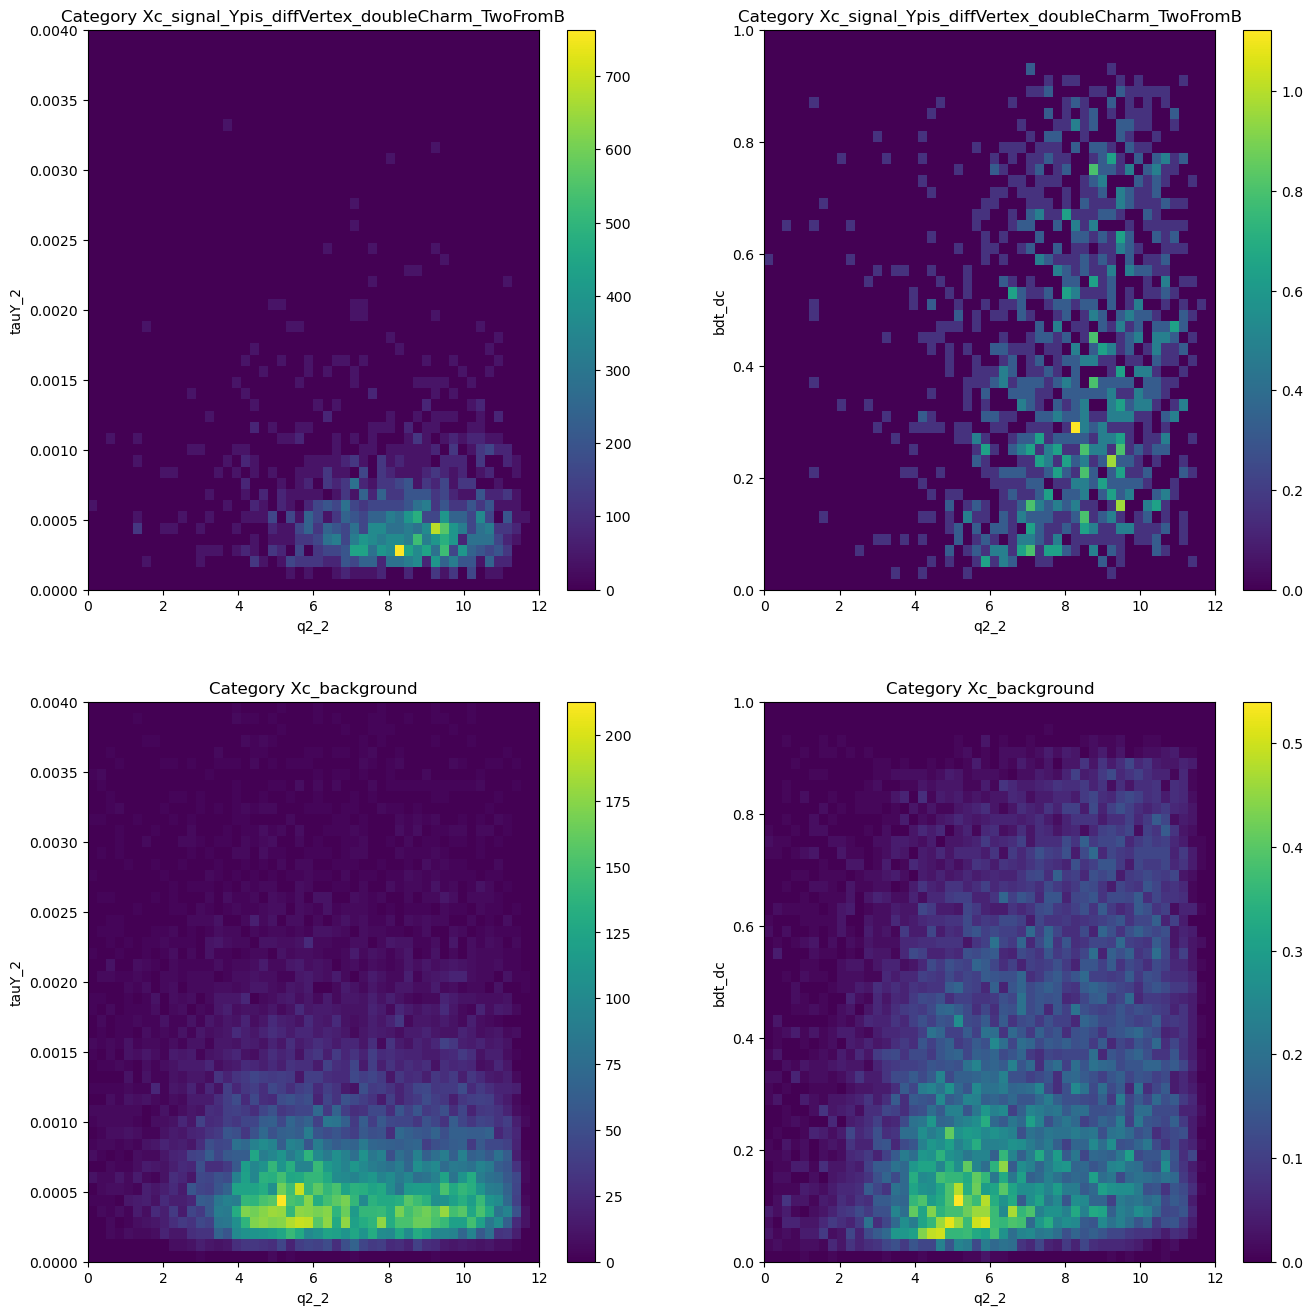

In [48]:
category1 = 15
category2 = 0


print(f.categories_map[category1])
print(f.categories_map[category2])



dftmp1 = dfbm2.query(f"category == {category1}")
dftmp2 = dfbm2.query(f"category == {category2}")

fig, axs = plt.subplots(2, 2, figsize=(16, 16))
myplot(dftmp1, category1, 'q2_2', 'tauY_2', axs[0][0])
myplot(dftmp2, category2, 'q2_2', 'tauY_2', axs[1][0])
myplot(dftmp1, category1, 'q2_2', 'bdt_dc', axs[0][1])
myplot(dftmp2, category2, 'q2_2', 'bdt_dc', axs[1][1])
fig.savefig(f"2D_corr_{category1}_{category2}.png")

In [37]:
# This is the list of categories handled by the group1 categorization - the OTHERS are esigned by "others"
group1_included = []
for c in group1:
    if c == 'others':
        continue
    elif type(c) == list:
        group1_included += [ cc for cc in c if cc != 'others' ]
    else:
        group1_included.append(c)
print(group1_included)

[18, 29, 23, 24, 10, 11, 15, 0, 16, 14, 25, 7, 19, 13, 27, 22, 20, 26, 21]


In [38]:
group1

[18,
 29,
 23,
 [24, 10, 11],
 [15, 0, 'others'],
 [16, 14],
 [25, 7, 19, 13],
 [27, 22],
 20,
 26,
 21]

In [39]:
all_bkgcategs = set(f.categories_map.keys())
others = all_bkgcategs - set(group1_included)

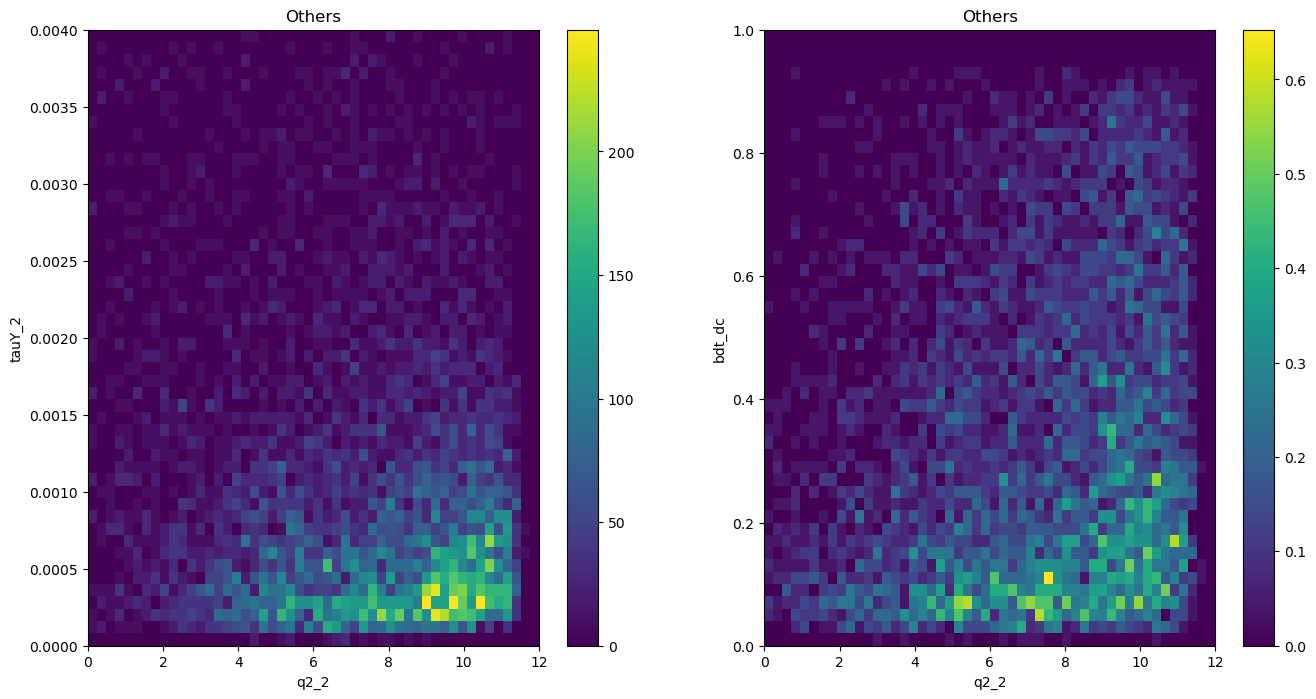

In [44]:
dfothers = dfbm2.query(f"category in  {list(others)}")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
myplot(dfothers, 999, 'q2_2', 'tauY_2', ax1)
myplot(dfothers, 999, 'q2_2', 'bdt_dc', ax2)
fig.savefig(f"2D_corr_others.png")

In [77]:
dfothers

,BDT_Iso,B_BPVVDR,B_M,B_P,B_Y_SEP,B_correctedMass,B_pT_Bdir,PBsn,PBv,PBvn,...,log(abs(PBsn)),log(abs(PBv/B_P)),log(abs(PBvn/B_P)),log(abs((PBsn-PBvn)/PBvn)),log(sqrt(abs(mDs2vn))),log(Y_PE),diff_m2pi,bdt_dc,group1_category,group1_name
6,0.041059,1.635162,3358.738751,138358.064637,-5.728818,4224.916779,777.387595,192702.501519,213022.409669,193222.400920,...,12.168903,0.431552,0.333997,-5.917962,7.758733,10.541215,275.667789,0.249087,4,"diffVertex_doubleCharm_TwoFromB, Xc_background, others"
30,0.299331,2.673479,3737.182629,89670.128173,-6.650825,3938.701837,196.363958,93085.589325,101870.604355,93097.159121,...,11.441275,0.127566,0.037506,-8.993001,7.555328,10.032096,219.114971,0.036646,4,"diffVertex_doubleCharm_TwoFromB, Xc_background, others"
59,0.146928,0.908533,4822.426360,95874.848080,-214.167678,7594.180176,2265.930999,75235.036058,77308.799106,76344.741737,...,11.228372,-0.215236,-0.227785,-4.231164,7.464594,10.474905,614.112575,0.047223,4,"diffVertex_doubleCharm_TwoFromB, Xc_background, others"
129,0.118465,2.813059,3146.605790,53511.022800,-5.674303,3716.488218,526.189839,53062.235186,61786.626584,56380.100576,...,10.879221,0.143799,0.052229,-2.832795,7.962198,9.886620,163.328164,0.440018,4,"diffVertex_doubleCharm_TwoFromB, Xc_background, others"
146,0.253561,4.634564,4262.860777,254361.455187,-5.110250,7823.037692,2750.078577,179641.451306,183182.457881,180095.016563,...,12.098718,-0.328274,-0.345272,-5.984101,7.873380,11.875701,73.170866,0.181968,4,"diffVertex_doubleCharm_TwoFromB, Xc_background, others"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242637,0.254442,2.124364,3350.702911,66972.296137,-9.963435,5170.482222,1499.538703,22368.108969,23229.919209,23792.096737,...,10.015392,-1.058838,-1.034926,-2.815892,7.956278,10.475185,64.621909,0.848526,4,"diffVertex_doubleCharm_TwoFromB, Xc_background, others"
242680,0.134811,4.367307,3455.532665,200462.837399,-29.916796,4661.140081,1049.691780,92750.597061,108120.891059,108154.221461,...,11.437669,-0.617379,-0.617071,-1.948955,7.384889,11.572352,177.704736,0.135759,4,"diffVertex_doubleCharm_TwoFromB, Xc_background, others"
242709,0.283556,2.625859,4215.061091,254685.259619,-11.816571,4881.332252,620.800249,291368.055233,305297.974632,299115.432788,...,12.582343,0.181260,0.160801,-3.653475,7.849205,11.680206,473.316191,0.356667,4,"diffVertex_doubleCharm_TwoFromB, Xc_background, others"
242728,0.299081,3.732498,3449.593454,191235.470501,-4.900037,5165.208898,1430.696052,104479.382065,152697.037294,152320.477076,...,11.556745,-0.225050,-0.227519,-1.158102,7.870213,11.457336,205.322881,0.353511,4,"diffVertex_doubleCharm_TwoFromB, Xc_background, others"


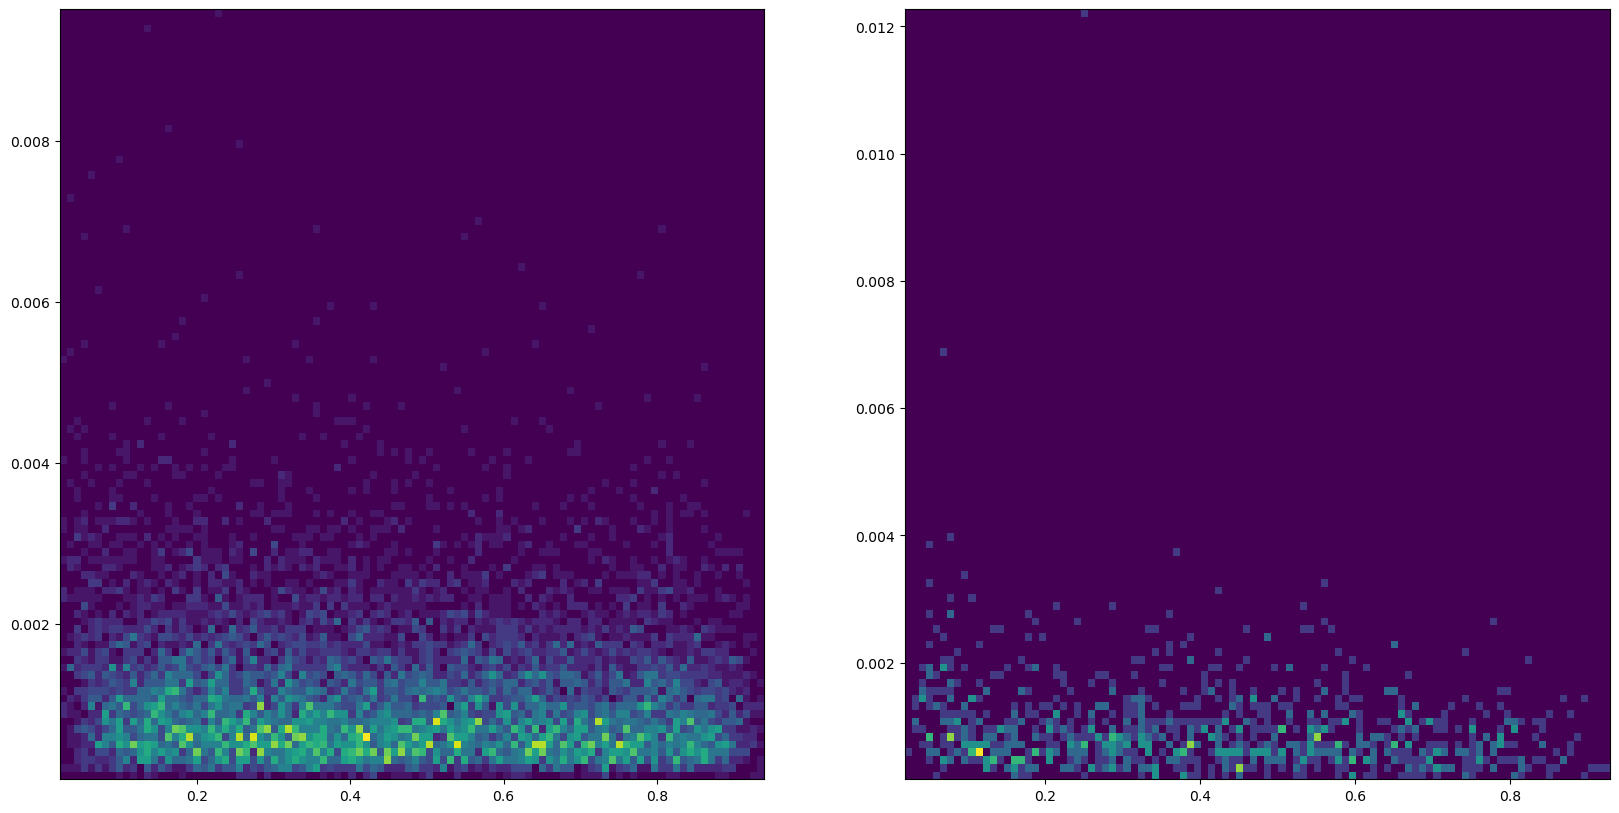

In [35]:
dftmp1 = dfbm2.query("category == 22")
dftmp2 = dfbm2.query("category == 27")
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.hist2d(dftmp1['bdt_dc'], dftmp1['tauY_2'], bins=100);
ax2.hist2d(dftmp2['bdt_dc'], dftmp2['tauY_2'], bins=100);

# TODO: Finish the study for all groups in categorization 